This is a Biopharming project simulating producing Aβ1-42 protein in Moss to use as vaccine for human against Alzheimer's diseases.

Importing necessary libraries before starting gathering data


In [ ]:
from Bio import SeqIO, Seq
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction
from Bio.SeqUtils import CodonAdaptationIndex
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Step 1: Gathering Data
- Step 1.1: Aβ1-42 protein and DNA Seq (literature/NCBI)
- Step 1.2: Moss Codon Table

Step 1.1: Aβ1-42 sequences: Standard human sequence (DAEFRHDSGYEVHHQKLVFFAEDVGSNKGAIIGLMVGGVVIA).

In [2]:
#load Aβ1-42 protein seq
abeta_protein = Seq("DAEFRHDSGYEVHHQKLVFFAEDVGSNKGAIIGLMVGGVVIA")

#load Aβ1-42 DNA seq
abeta_dna = Seq("GATGCTGAGTTCCGCCATGACAGCGGCTACGAGGTGCACCACCAGAAGCTGGTGTTCTTCGCTGAGGACGTGGGCAGCAACAAGGGCGCCATCATCGGCCTGATGGTGGGCGGCGTGGTGATCGCC")

print("Aβ1-42 Protein:", abeta_protein)
print("Initial DNA:", abeta_dna)

Aβ1-42 Protein: DAEFRHDSGYEVHHQKLVFFAEDVGSNKGAIIGLMVGGVVIA
Initial DNA: GATGCTGAGTTCCGCCATGACAGCGGCTACGAGGTGCACCACCAGAAGCTGGTGTTCTTCGCTGAGGACGTGGGCAGCAACAAGGGCGCCATCATCGGCCTGATGGTGGGCGGCGTGGTGATCGCC


Step 1.2: Moss Codon Table

In [3]:
# Load Moss Codon Table
# Frequency per thousand; for CAI calculation
moss_codons = {
    'UUU': 17.2, 'UCU': 15.0, 'UAU': 10.5, 'UGU': 7.0,
    'UUC': 23.6, 'UCC': 11.8, 'UAC': 17.2, 'UGC': 9.8,
    'UUA': 1.0, 'UCA': 10.2, 'UAA': 0.9, 'UGA': 1.2,
    'UUG': 23.6, 'UCG': 6.7, 'UAG': 0.7, 'UGG': 14.3,
    'CUU': 16.8, 'CCU': 14.6, 'CAU': 9.3, 'CGU': 6.8,
    'CUC': 18.2, 'CCC': 9.8, 'CAC': 12.7, 'CGC': 8.5,
    'CUA': 7.3, 'CCA': 12.3, 'CAA': 14.6, 'CGA': 5.8,
    'CUG': 25.6, 'CCG': 7.2, 'CAG': 19.8, 'CGG': 6.4,
    'AUU': 17.0, 'ACU': 12.5, 'AAU': 13.8, 'AGU': 9.6,
    'AUC': 23.0, 'ACC': 15.8, 'AAC': 22.0, 'AGC': 12.7,
    'AUA': 4.5, 'ACA': 10.8, 'AAA': 13.6, 'AGA': 11.9,
    'AUG': 22.0, 'ACG': 7.0, 'AAG': 25.4, 'AGG': 10.8,
    'GUU': 16.8, 'GCU': 16.4, 'GAU': 12.7, 'GGU': 12.2,
    'GUC': 18.5, 'GCC': 13.8, 'GAC': 18.3, 'GGC': 14.3,
    'GUA': 4.8, 'GCA': 12.8, 'GAA': 18.0, 'GGA': 13.8,
    'GUG': 22.0, 'GCG': 7.5, 'GAG': 24.5, 'GGG': 10.5
}

# cai = CodonAdaptationIndex()
# cai.set_cai_index(moss_codons)

Step 2: Preprocess Data
- Clean Aβ1-42 DNA sequence. (here we check if our protein seq is match with our translated DNA( both its number(42) and its seq)).
- Simulated RNA-seq data with placeholder DataFrame.

In [4]:
# Step 2.1: Verify Aβ1-42 Sequence
# Check length and translate to confirm
if len(abeta_protein) == 42 and abeta_dna.translate() == abeta_protein:
    print("Aβ1-42 DNA translates correctly to protein.")
else:
    print("Sequence error; check DNA.")

# Step 2.2: Simulate RNA-seq Data
# Features: gc_content, cai, promoter_strength, glycosylation_score; Label: expression_level
data = pd.DataFrame({
    'gc_content': np.random.uniform(0.3, 0.7, 100),
    'cai': np.random.uniform(0.6, 1.0, 100),
    'promoter_strength': np.random.uniform(0.7, 1.0, 100),
    'glycosylation_score': np.random.uniform(0.5, 1.0, 100),
    'expression_level': np.random.choice([0, 1], 100)  # 0=low, 1=high
})

# Normalize (example)
data['gc_content_norm'] = np.log(data['gc_content'] + 1)
print("RNA-seq Data Sample:", data.head())

Aβ1-42 DNA translates correctly to protein.
RNA-seq Data Sample:    gc_content       cai  promoter_strength  glycosylation_score  \
0    0.417212  0.660387           0.823640             0.542445   
1    0.570484  0.704375           0.838407             0.957496   
2    0.557585  0.907556           0.844017             0.957047   
3    0.514284  0.821278           0.891169             0.622737   
4    0.382083  0.633206           0.703467             0.636788   

   expression_level  gc_content_norm  
0                 0         0.348692  
1                 0         0.451384  
2                 0         0.443136  
3                 0         0.414943  
4                 1         0.323592  


Step 3: Codon optimization and Calculate features
- Step 3.1: Different codons can encode the same amino acids; since each may lead to higher expression levels in our host organism, we replace the protein's RNA codons with those preferred by the host.
- Step 3.2: cai_estimate value in simulated here in this project.

In [5]:
# Step 3.1: Simplified Codon Optimization
# Replace human codons with moss-preferred (e.g., CTG→TTG for leucine)
optimized_dna = abeta_dna.replace("CTG", "TTG").replace("GCT", "GCC")  # Example swaps

print("Optimized DNA:", optimized_dna)

# Step 3.2: Calculate Features
gc = gc_fraction(optimized_dna)

cai_estimate = 0.85  # Simulated
print("GC Content:", gc)
print("CAI (estimate):", cai_estimate)

Optimized DNA: GATGTTGAGTTCCGCCATGACAGCGGCCACGAGGTGCACCACCAGAAGTTGGTGTTCTTCGTTGAGGACGTGGGCAGCAACAAGGGCGCCATCATCGGCCTGATGGTGGGCGGCGTGGTGATCGCC
GC Content: 0.6190476190476191
CAI (estimate): 0.85


Step 4: Build Construct
- Construct = Promoter + Optimized DNA + Terminator
- Promoter = Placeholder PpEF1α
- Terminator = Standard NOS

In [6]:
# Promoter: Placeholder PpEF1α (TATATAA: a common promoter element in eukaryotes that initiates transcriptionuse; add 493 "N" as nucleotides to approximate real length of the promoter)
promoter = Seq("TATATAA" + "N" * 493)  # 500 bp placeholder
# NOS terminator signal the end of transcription for a transgene
terminator = Seq("GATCGTTCAAACATTTGGCAATAAAGTTTCTTAAGATTGAATCCTGTTGCCGGTCTTGCGATGATTATCATATAATTTCTGTTGAATTACGTTAAGCATGTAATAATTAACATGTAATGCATGACGTTATTTATGAGATGGGTTTTTATGATTAGAGTCCCGCAATTATACATTTAATACGCGATAGAAAACAAAATATAGCGCGCAAACTAGGATAAATTATCGCGCGCGGTGTCATCTATGTTACTAGATC")

construct = promoter + optimized_dna + terminator
print("Full Construct Length:", len(construct))

Full Construct Length: 879


Step 5: Train and Predict

In [7]:
X = data[['gc_content', 'cai', 'promoter_strength', 'glycosylation_score']]
y = data['expression_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, predictions))

# Predict for our construct
new_features = pd.DataFrame({
    'gc_content': [gc],
    'cai': [cai_estimate],
    'promoter_strength': [0.9],  # Assume strong PpEF1α
    'glycosylation_score': [0.8]  # Moss-specific PTM advantage
}, index=[0])
pred = model.predict(new_features)
print("Predicted Expression (0=low, 1=high):", pred[0])

Model Accuracy: 0.45
Predicted Expression (0=low, 1=high): 0


Step 6: Visualizations


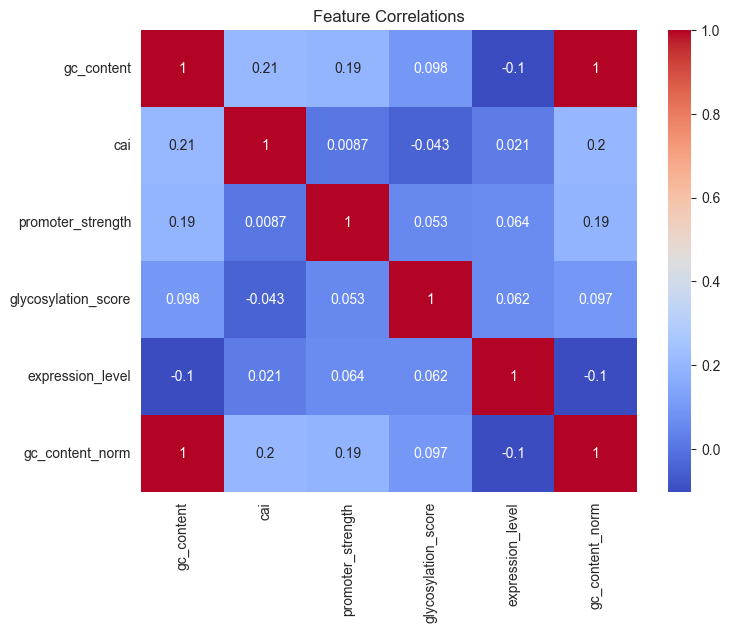

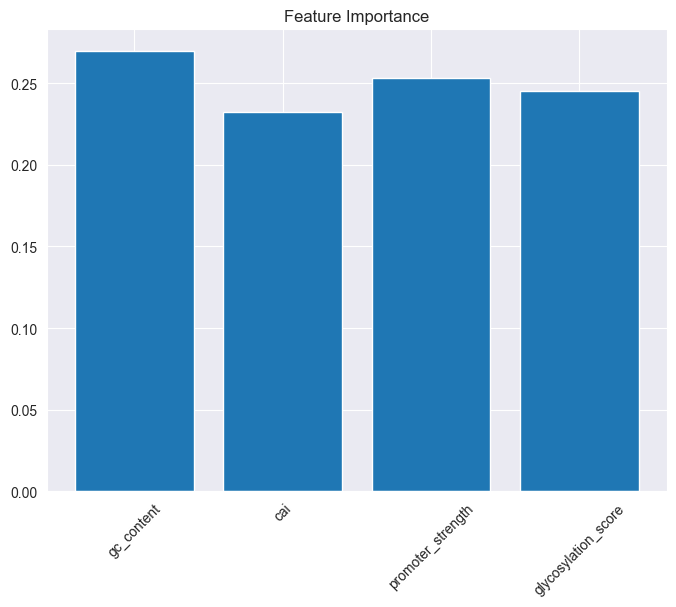

In [8]:
# Step 6.1: Correlation heatmap (the more red each square is, the more correlation two features have; e.g., higher cai leads to higher expression_level).
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlations")
plt.show()

# Step 6.2: Feature importance (this plot indicates which features most strongly influence the Aβ1-42 DNA construct for higher expression levels in moss).
plt.figure(figsize=(8, 6))
plt.bar(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()